# Library Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Initial Conditions and Constants

In [23]:
m1 = 1.0
m2 = 1.0
m3 = 1.0

#Initial position
init_pos1 = np.array([1.0, 0.0, 1.0])
init_pos2 = np.array([1.0, 1.0, 0.0])
init_pos3 = np.array([0.0, 1.0, 1.0])

#Initial velocity
init_vel1 = np.array([0.0, 0.0, -1.0])
init_vel2 = np.array([0.0, 0.0, 1.0])
init_vel3 = np.array([0.0, 0.0, -0.6])

init_conditions = np.array([
    init_pos1, init_pos2, init_pos3, 
    init_vel1, init_vel2, init_vel3
]).ravel()

# Defining the system of ODEs

In [24]:
def system_ode(t, S, m1, m2, m3):

    p1, p2, p3 = S[0:3], S[3:6], S[6:9]
    dp1_dt, dp2_dt, dp3_dt = S[9:12], S[12:15], S[15:18]

    f1, f2, f3 = dp1_dt, dp2_dt, dp3_dt

    df1_dt = m3 * (p3 - p1) / np.linalg.norm(p3 - p1)**3 + m2 * (p2 - p1) / np.linalg.norm(p2 - p1)**3
    df2_dt = m3 * (p3 - p2) / np.linalg.norm(p3 - p2)**3 + m1 * (p1 - p2) / np.linalg.norm(p1 - p2)**3
    df3_dt = m1 * (p1 - p3) / np.linalg.norm(p1 - p3)**3 + m2 * (p2 - p3) / np.linalg.norm(p2 - p3)**3

    return np.array([f1, f2, f3, df1_dt, df2_dt, df3_dt]).ravel()

# Solving the problem

In [25]:
time_s, time_e = 0, 10
t_points = np.linspace(time_s, time_e, 1001)

solution = solve_ivp(
    fun = system_ode,
    t_span = (time_s, time_e),
    y0 = init_conditions,
    t_eval = t_points,
    args = (m1, m2, m3)
)

t_sol = solution.t

p1x_sol = solution.y[0]
p1y_sol = solution.y[1]
p1z_sol = solution.y[2]

p2x_sol = solution.y[3]
p2y_sol = solution.y[4]
p2z_sol = solution.y[5]

p3x_sol = solution.y[6]
p3y_sol = solution.y[7]
p3z_sol = solution.y[8]

 # Plotting the Results

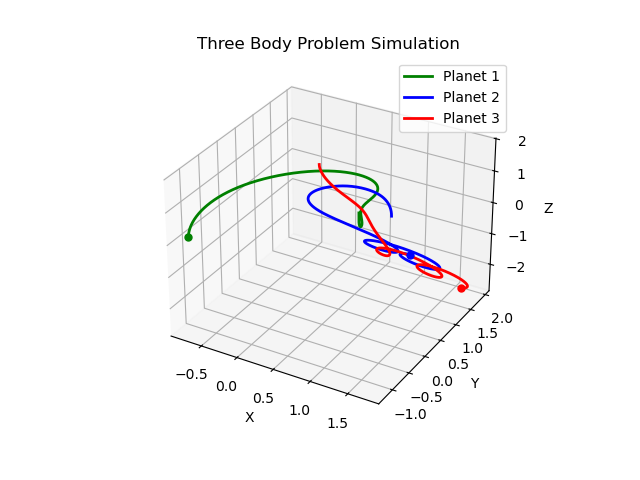

In [26]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

planet1_plt = ax.plot(p1x_sol, p1y_sol, p1z_sol, "green", label='Planet 1', linewidth=2)
planet2_plt = ax.plot(p2x_sol, p2y_sol, p2z_sol, "blue", label='Planet 2', linewidth=2)
planet3_plt = ax.plot(p3x_sol, p3y_sol, p3z_sol, "red", label='Planet 3', linewidth=2)

planet1_dot = ax.plot([p1x_sol[-1]], [p1y_sol[-1]], [p1z_sol[-1]], "o", color="green", markersize=5)
planet2_dot = ax.plot([p2x_sol[-1]], [p2y_sol[-1]], [p2z_sol[-1]], "o", color="blue", markersize=5)
planet3_dot = ax.plot([p3x_sol[-1]], [p3y_sol[-1]], [p3z_sol[-1]], "o", color="red", markersize=5)

ax.set_title("Three Body Problem Simulation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.grid()
plt.legend()
plt.show()

# Interesting inital conditions:

## Title: helicopter
 mass = 1.0
- pos = [-0.5, 0.0, 0.0], [0.5, 0.0, 0.0], [0.0, 0.0, 1.0]
- vel = [0.0, 0.347111, 0], [0.0, -0.347111, 0], [0.0, 0.0, -0.1]

## Title: figure 8
- mass = 1.0
- pos = [ 0.97000436, -0.24308753, 0.0], [-0.97000436, 0.24308753, 0.0], [0.0, 0.0, 0.0]
- vel = [0.93240737/2, 0.86473146/2, 0.0], [0.93240737/2, 0.86473146/2, 0.0], [-0.93240737, -0.86473146, 0.0]

## Title: chaos
- mass = 1.0, 1.0, 1.1
- pos = [-1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, 0.0]
- vel = [0.0, 0.5, 0.1], [0.0, -0.5, 0.1], [0.0, 0.0, -0.2]


# Final code along with animations

- Note: Copy and paste the code below into a .py file or the animation  won't work. Alternatively, you could do "pip install ipympl" then run the code below.

Solved in 0.7309 seconds


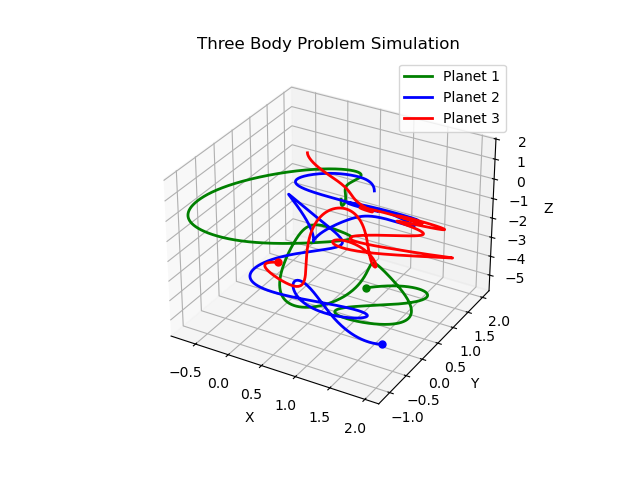

In [ ]:
%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time

# Masses of the planets/bodies relative to earth's mass (e.g. 1.0 means same mass as Earth)
m1 = 1.0
m2 = 1.0
m3 = 1.0

#Initial position
init_pos1 = np.array([1.0, 0.0, 1.0])
init_pos2 = np.array([1.0, 1.0, 0.0])
init_pos3 = np.array([0.0, 1.0, 1.0])

#Initial velocity
init_vel1 = np.array([0.0, 0.0, -1.0])
init_vel2 = np.array([0.0, 0.0, 1.0])
init_vel3 = np.array([0.0, 0.0, -0.6])

init_conditions = np.array([
    init_pos1, init_pos2, init_pos3, 
    init_vel1, init_vel2, init_vel3
]).ravel()

def system_ode(t, S, m1, m2, m3):

    p1, p2, p3 = S[0:3], S[3:6], S[6:9]
    dp1_dt, dp2_dt, dp3_dt = S[9:12], S[12:15], S[15:18]

    f1, f2, f3 = dp1_dt, dp2_dt, dp3_dt

    df1_dt = m3 * (p3 - p1) / np.linalg.norm(p3 - p1)**3 + m2 * (p2 - p1) / np.linalg.norm(p2 - p1)**3
    df2_dt = m3 * (p3 - p2) / np.linalg.norm(p3 - p2)**3 + m1 * (p1 - p2) / np.linalg.norm(p1 - p2)**3
    df3_dt = m1 * (p1 - p3) / np.linalg.norm(p1 - p3)**3 + m2 * (p2 - p3) / np.linalg.norm(p2 - p3)**3

    return np.array([f1, f2, f3, df1_dt, df2_dt, df3_dt]).ravel()

time_s, time_e = 0, 30
t_points = np.linspace(time_s, time_e, 1501)

t1 = time.time()

solution = solve_ivp(
    fun = system_ode,
    t_span = (time_s, time_e),
    y0 = init_conditions,
    t_eval = t_points,
    args = (m1, m2, m3),
    rtol=1e-10,
    atol=1e-12,
    method='DOP853'
)

t2 = time.time()

print(f"Solved in {t2 - t1:.4f} seconds")

t_sol = solution.t

p1x_sol = solution.y[0]
p1y_sol = solution.y[1]
p1z_sol = solution.y[2]

p2x_sol = solution.y[3]
p2y_sol = solution.y[4]
p2z_sol = solution.y[5]

p3x_sol = solution.y[6]
p3y_sol = solution.y[7]
p3z_sol = solution.y[8]

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

planet1_plt, = ax.plot(p1x_sol, p1y_sol, p1z_sol, "green", label='Planet 1', linewidth=2)
planet2_plt, = ax.plot(p2x_sol, p2y_sol, p2z_sol, "blue", label='Planet 2', linewidth=2)
planet3_plt, = ax.plot(p3x_sol, p3y_sol, p3z_sol, "red", label='Planet 3', linewidth=2)

planet1_dot, = ax.plot([p1x_sol[-1]], [p1y_sol[-1]], [p1z_sol[-1]], "o", color="green", markersize=5)
planet2_dot, = ax.plot([p2x_sol[-1]], [p2y_sol[-1]], [p2z_sol[-1]], "o", color="blue", markersize=5)
planet3_dot, = ax.plot([p3x_sol[-1]], [p3y_sol[-1]], [p3z_sol[-1]], "o", color="red", markersize=5)

ax.set_title("Three Body Problem Simulation")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.grid()
plt.legend()


from matplotlib.animation import FuncAnimation

def update(frame):
    x_current1 = p1x_sol[0:frame+1]
    y_current1 = p1y_sol[0:frame+1]
    z_current1 = p1z_sol[0:frame+1]

    x_current2 = p2x_sol[0:frame+1]
    y_current2 = p2y_sol[0:frame+1]
    z_current2 = p2z_sol[0:frame+1]

    x_current3 = p3x_sol[0:frame+1]
    y_current3 = p3y_sol[0:frame+1]
    z_current3 = p3z_sol[0:frame+1]

    planet1_plt.set_data(x_current1, y_current1)
    planet1_plt.set_3d_properties(z_current1)

    planet1_dot.set_data([x_current1[-1]], [y_current1[-1]])
    planet1_dot.set_3d_properties([z_current1[-1]])

    planet2_plt.set_data(x_current2, y_current2)
    planet2_plt.set_3d_properties(z_current2)

    planet2_dot.set_data([x_current2[-1]], [y_current2[-1]])
    planet2_dot.set_3d_properties([z_current2[-1]])

    planet3_plt.set_data(x_current3, y_current3)
    planet3_plt.set_3d_properties(z_current3)

    planet3_dot.set_data([x_current3[-1]], [y_current3[-1]])
    planet3_dot.set_3d_properties([z_current3[-1]])

    return planet1_plt, planet1_dot, planet2_plt, planet2_dot, planet3_plt, planet3_dot

animation = FuncAnimation(fig, update, frames=range(0, len(t_points), 1), interval=10, blit=True)
plt.show()

# Error Analysis

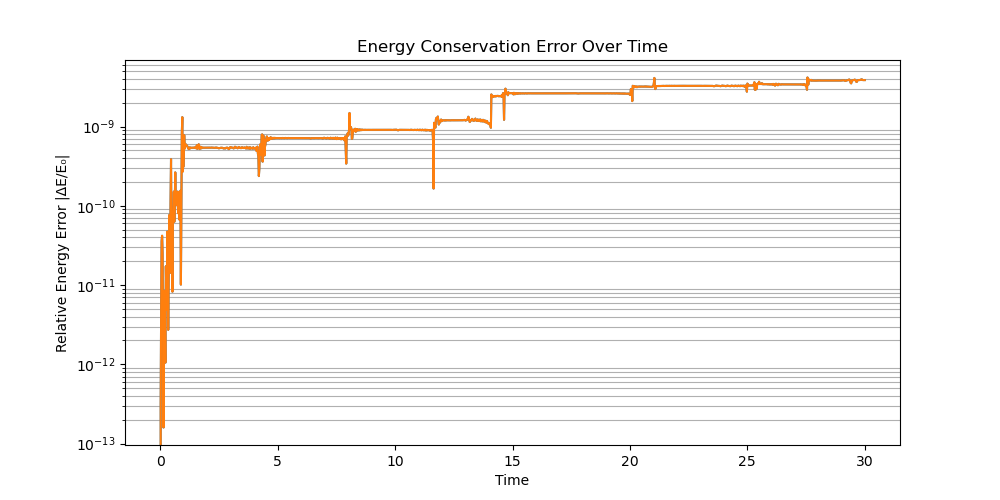

In [31]:
d12 = np.linalg.norm(solution.y[0:3] - solution.y[3:6], axis=0)
d13 = np.linalg.norm(solution.y[0:3] - solution.y[6:9], axis=0)
d23 = np.linalg.norm(solution.y[3:6] - solution.y[6:9], axis=0)

# Extract velocities from solution
v1 = solution.y[9:12]   # shape (3, N)
v2 = solution.y[12:15]
v3 = solution.y[15:18]

# Kinetic energy
KE = 0.5 * (m1 * np.sum(v1**2, axis=0) +
             m2 * np.sum(v2**2, axis=0) +
             m3 * np.sum(v3**2, axis=0))

# Potential energy (G=1 implicitly)
PE = (-m1*m2 / d12 - m1*m3 / d13 - m2*m3 / d23)

E_total = KE + PE
E0 = E_total[0]

relative_energy_error = np.abs((E_total - E0) / E0)

plt.semilogy(t_sol, relative_energy_error)
plt.xlabel("Time")
plt.ylabel("Relative Energy Error |ΔE/E₀|")
plt.title("Energy Conservation Error Over Time")
plt.grid()
plt.show()